Scraping

In [ ]:
import requests
from bs4 import BeautifulSoup
import os
import time
import re
from google.colab import drive

# --- 1. SETUP ---
print("🔒 Memulai Sistem V40 (Double Lock Verification)...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 2. KONFIGURASI ---
BASE_DRIVE_PATH = "/content/drive/MyDrive/UBS Image Retrieval/dataset_v40_clean"
BASE_DOMAIN = "https://ubslifestyle.com"

CATEGORY_MAP = {
    "earrings": ["anting", "earring", "giwang"],
    "rings": ["cincin", "ring"],
    "necklaces": ["kalung", "necklace", "choker"],
    "bracelets": ["gelang", "bracelet", "bangle"],
    "pendants": ["liontin", "pendant", "charm"]
}

# Daftar Kode Angle yang diterima
# AR/BR/CR = Rose Gold
# AW/BW/CW = White Gold
# AY/BY/CY = Yellow Gold
VALID_SUFFIXES = [
    '_AR', '_BR', '_CR',
    '_AW', '_BW', '_CW',
    '_AY', '_BY', '_CY'
]

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Referer": "https://ubslifestyle.com/"
}

# --- 3. FUNGSI ---

def clean_image_url(url):
    """
    Menghapus dimensi resize agar mendapatkan gambar HD.
    Contoh: AWY0037_CW-290x290.jpg -> AWY0037_CW.jpg
    """
    url = url.replace('\\/', '/')
    return re.sub(r'-\d+x\d+(?=\.\w{3,4}$)', '', url)

def extract_sku_from_h1(soup):
    """
    Mengambil SKU dari H1. Ini adalah SOURCE OF TRUTH.
    """
    h1 = soup.find("h1", class_="materializer")
    if not h1: h1 = soup.find("h1", class_="product_title")
    if not h1: h1 = soup.find("h1")

    if not h1: return None, None

    full_title = h1.text.strip()

    # Logic: Split by '-'
    # Contoh: "UBS Anting... - AWY0037 - 17K"
    parts = full_title.split('-')
    sku = None

    for part in parts:
        clean_part = part.strip()
        # Kode harus alfanumerik (huruf+angka) tanpa spasi
        if any(char.isdigit() for char in clean_part) and " " not in clean_part:
            if 3 < len(clean_part) < 15:
                sku = clean_part
                break

    # Fallback jika format judul beda
    if not sku:
        match = re.search(r'\b[A-Z]{1,3}\d+[A-Z0-9]*\b', full_title)
        if match: sku = match.group(0)

    return sku, full_title

def download_file(img_url, save_path, filename):
    try:
        # Selalu coba download versi bersih (HD)
        hd_url = clean_image_url(img_url)
        r = requests.get(hd_url, headers=HEADERS, timeout=10)

        if r.status_code == 200:
            with open(os.path.join(save_path, filename), 'wb') as f:
                f.write(r.content)
            return True
        else:
            # Fallback ke URL asli
            r = requests.get(img_url, headers=HEADERS, timeout=10)
            if r.status_code == 200:
                with open(os.path.join(save_path, filename), 'wb') as f:
                    f.write(r.content)
                return True
    except: pass
    return False

def scrape_product_v40(product_url, category_path):
    try:
        r = requests.get(product_url, headers=HEADERS, timeout=10)
        if r.status_code != 200: return

        # raw_html digunakan untuk regex global (mencari semua link gambar di page)
        raw_html = r.text
        soup = BeautifulSoup(r.content, "html.parser")

        # 1. AMBIL SKU (Parameter Utama)
        sku, raw_title = extract_sku_from_h1(soup)
        if not sku: return

        # Buat Folder sesuai SKU
        product_save_path = os.path.join(category_path, sku)
        if not os.path.exists(product_save_path): os.makedirs(product_save_path)

        # Cek jika folder sudah terisi
        if len(os.listdir(product_save_path)) >= 1: return

        # 2. CARI SEMUA KANDIDAT GAMBAR
        # Kita ambil semua link gambar di halaman, tapi nanti disaring ketat.
        pattern = r'(https?://[^"\'\s>]+?\.(?:jpg|png|jpeg))'
        found_urls = re.findall(pattern, raw_html, re.IGNORECASE)

        unique_urls = sorted(list(set(found_urls)))

        saved_count = 0

        # 3. FILTER DOUBLE LOCK (SKU MATCH + SUFFIX MATCH)
        for url in unique_urls:
            u_upper = url.upper()
            sku_upper = sku.upper()

            # --- LOCK 1: VALIDASI SKU ---
            # URL Gambar WAJIB mengandung SKU produk utama.
            # Ini mencegah "AR Nyasar" dari related products.
            if sku_upper not in u_upper:
                continue # Skip gambar yang bukan milik produk ini

            # --- LOCK 2: VALIDASI SUFFIX (ANGLE) ---
            detected_suffix = None
            for valid in VALID_SUFFIXES:
                if valid in u_upper:
                    detected_suffix = valid.replace('_', '') # AW, BW, CR, dst
                    break

            # Jika tidak ada suffix AR/BR/CW, skip.
            if not detected_suffix:
                continue

            # --- PROSES DOWNLOAD ---
            # Nama File: SKU_SUFFIX.jpg (Contoh: AWY0037_CW.jpg)
            fname = f"{sku}_{detected_suffix}.jpg"

            if os.path.exists(os.path.join(product_save_path, fname)): continue

            if download_file(url, product_save_path, fname):
                saved_count += 1

        if saved_count > 0:
            print(f"      [OK] {sku} ({saved_count} img) -> Clean Match")
        else:
            # Hapus folder jika kosong
            try: os.rmdir(product_save_path)
            except: pass

    except Exception: pass

# --- RUN ---
def run_scraper_v40():
    if not os.path.exists(BASE_DRIVE_PATH):
        try: os.makedirs(BASE_DRIVE_PATH)
        except: return

    print("=== MULAI V40 (FINAL CLEAN) ===")

    for category, keywords in CATEGORY_MAP.items():
        print(f"\n>>> Kategori: {category.upper()}")
        cat_path = os.path.join(BASE_DRIVE_PATH, category)
        if not os.path.exists(cat_path): os.makedirs(cat_path)

        page = 1
        empty_streak = 0

        while True:
            url = f"{BASE_DOMAIN}/products/?jewelry={category}" if page == 1 else f"{BASE_DOMAIN}/products/page/{page}/?jewelry={category}"
            print(f"   [Page {page}] Scanning...")

            try:
                r = requests.get(url, headers=HEADERS, timeout=15)
                if r.status_code == 404: break

                soup = BeautifulSoup(r.content, "html.parser")

                links = []
                for a in soup.find_all("a", href=True):
                    href = a['href']
                    if "ubslifestyle.com" in href and "/products/" not in href and "/page/" not in href:
                        if any(kw in href.lower() for kw in keywords) or category in href:
                            links.append(href)

                unique_links = list(set(links))

                if not unique_links:
                    empty_streak += 1
                    if empty_streak > 2: break
                else:
                    empty_streak = 0
                    print(f"   -> Memproses {len(unique_links)} link...")
                    for link in unique_links:
                        scrape_product_v40(link, cat_path)

                page += 1
                if page > 50: break

            except Exception:
                time.sleep(2)

    print("\n=== SELESAI ===")

if __name__ == "__main__":
    run_scraper_v40()

🔒 Memulai Sistem V40 (Double Lock Verification)...
=== MULAI V40 (FINAL CLEAN) ===

>>> Kategori: EARRINGS
   [Page 1] Scanning...
   -> Memproses 16 link...
      [OK] CAB0576K (3 img) -> Clean Match
      [OK] AWY0036 (3 img) -> Clean Match
      [OK] CWB1026 (3 img) -> Clean Match
      [OK] CAY0037 (3 img) -> Clean Match
      [OK] AWY0037 (3 img) -> Clean Match
      [OK] ZAVp000004k (3 img) -> Clean Match
      [OK] AAY0126 (3 img) -> Clean Match
      [OK] AAY0122 (3 img) -> Clean Match
      [OK] AWY0035 (3 img) -> Clean Match
      [OK] CWB1055K (3 img) -> Clean Match
   [Page 2] Scanning...
   -> Memproses 16 link...
      [OK] AWY0032 (3 img) -> Clean Match
      [OK] KSW1221K (3 img) -> Clean Match
      [OK] KSW1287 (1 img) -> Clean Match
      [OK] AAP1619 (3 img) -> Clean Match
      [OK] AWZ0019 (3 img) -> Clean Match
      [OK] KSW1290 (3 img) -> Clean Match
      [OK] AAP1618 (3 img) -> Clean Match
      [OK] CWB0996K (3 img) -> Clean Match
      [OK] CSW0920 (3 img) 

📊 Menganalisis dataset di: /content/drive/MyDrive/UBS Image Retrieval/dataset_v40_clean

=== 📋 RINGKASAN STATISTIK ===
 Kategori  Jumlah Produk  Total Gambar  Rata-rata Gambar/Produk
BRACELETS             78           264                     3.38
 EARRINGS            127           408                     3.21
NECKLACES            127           404                     3.18
 PENDANTS            202           626                     3.10
    RINGS            153           479                     3.13
------------------------------------------------------------
TOTAL KESELURUHAN: 687 Produk | 2181 Gambar
------------------------------------------------------------


/tmp/ipython-input-2530923572.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Kategori', y='Total Gambar', data=df, palette='viridis')


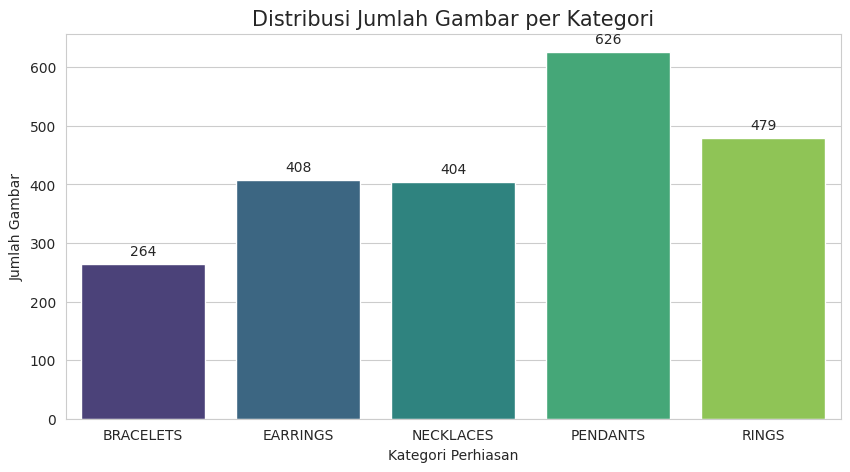

In [ ]:
# @title Cek Statistik Dataset (Tabel & Grafik)
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Setup
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- KONFIGURASI PATH ---
# Ganti path ini sesuai folder dataset terakhir Anda (V30 atau V31)
DATASET_PATH = "/content/drive/MyDrive/UBS Image Retrieval/dataset_v40_clean"

def analyze_dataset(base_path):
    if not os.path.exists(base_path):
        print(f"❌ Error: Path tidak ditemukan: {base_path}")
        return

    print(f"📊 Menganalisis dataset di: {base_path}\n")

    stats = []
    total_images_all = 0
    total_products_all = 0

    # Loop Kategori
    for category in sorted(os.listdir(base_path)):
        cat_path = os.path.join(base_path, category)

        if os.path.isdir(cat_path):
            n_products = 0
            n_images = 0

            # Loop Produk di dalam Kategori
            for product in os.listdir(cat_path):
                prod_path = os.path.join(cat_path, product)

                if os.path.isdir(prod_path):
                    n_products += 1
                    # Hitung file gambar (jpg/png)
                    imgs = [f for f in os.listdir(prod_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
                    n_images += len(imgs)

            # Simpan Data
            if n_products > 0:
                avg_img = n_images / n_products
            else:
                avg_img = 0

            stats.append({
                'Kategori': category.upper(),
                'Jumlah Produk': n_products,
                'Total Gambar': n_images,
                'Rata-rata Gambar/Produk': round(avg_img, 2)
            })

            total_images_all += n_images
            total_products_all += n_products

    # Buat DataFrame (Tabel)
    df = pd.DataFrame(stats)

    # Tampilkan Tabel
    print("=== 📋 RINGKASAN STATISTIK ===")
    print(df.to_string(index=False))
    print("-" * 60)
    print(f"TOTAL KESELURUHAN: {total_products_all} Produk | {total_images_all} Gambar")
    print("-" * 60)

    # --- VISUALISASI GRAFIK ---
    if not df.empty:
        plt.figure(figsize=(10, 5))

        # Plot Bar Chart
        sns.set_style("whitegrid")
        ax = sns.barplot(x='Kategori', y='Total Gambar', data=df, palette='viridis')

        # Tambahkan label angka di atas batang
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

        plt.title('Distribusi Jumlah Gambar per Kategori', fontsize=15)
        plt.ylabel('Jumlah Gambar')
        plt.xlabel('Kategori Perhiasan')
        plt.show()

# Jalankan Fungsi
analyze_dataset(DATASET_PATH)

In [ ]:
import torch
import os

DB_PATH = "/content/drive/MyDrive/UBS Image Retrieval/clip_database.pth"

print(f"--- INVESTIGASI FILE: {os.path.abspath(DB_PATH)} ---")

if not os.path.exists(DB_PATH):
    print("❌ ERROR: File tidak ditemukan! Cek nama file/lokasi.")
    exit()

try:
    # 2. Buka "Perut" File
    print("📂 Sedang membuka file...")
    # map_location='cpu' penting karena laptop mungkin tidak punya CUDA
    checkpoint = torch.load(DB_PATH, map_location=torch.device('cpu'))

    paths = checkpoint['paths']
    print(f"✅ File terbuka. Total data tersimpan: {len(paths)} item")

    # 3. Cari Si Hantu
    TARGET_HANTU = "CWY0025" # Potongan nama file yang error tadi
    ditemukan = False

    print(f"\n🔍 Mencari jejak '{TARGET_HANTU}'...")

    for i, p in enumerate(paths):
        if TARGET_HANTU in p:
            ditemukan = True
            print(f"\n⚠️ DITEMUKAN HANTU di Index-{i}!")
            print(f"   Path: {p}")
            break

    if not ditemukan:
        print(f"\n✅ BERSIH. String '{TARGET_HANTU}' TIDAK ADA di file ini.")
        print("   Kesimpulan: Masalah ada di CACHE STREAMLIT, bukan di file.")
    else:
        print(f"\n❌ KOTOR. String '{TARGET_HANTU}' MASIH ADA di file ini.")
        print("   Kesimpulan: File yang Anda download dari Drive adalah VERSI LAMA.")
        print("   (Google Drive sering telat sync/update).")

except Exception as e:
    print(f"❌ Gagal membuka file: {e}")

--- INVESTIGASI FILE: /content/drive/MyDrive/UBS Image Retrieval/clip_database.pth ---
📂 Sedang membuka file...
✅ File terbuka. Total data tersimpan: 1558 item

🔍 Mencari jejak 'CWY0025'...

⚠️ DITEMUKAN HANTU di Index-145!
   Path: /content/drive/MyDrive/UBS Image Retrieval/dataset_v31_validated/earrings/UBS Anting Emas Disney Princess Ariel - CWY0025 - 17K/UBS Anting Emas Disney Princess Ariel - CWY0025 - 17K_BR.jpg

❌ KOTOR. String 'CWY0025' MASIH ADA di file ini.
   Kesimpulan: File yang Anda download dari Drive adalah VERSI LAMA.
   (Google Drive sering telat sync/update).
